# KrediPin — Sistem Pendukung Keputusan Kelayakan Pinjaman Digital
### Notebook Pelatihan Model (XGBoost) — Tugas CBL DASD × SIAB

**Studi kasus.** Lembaga pembiayaan/fintech perlu memutuskan kelayakan pengajuan pinjaman
secara *data-driven*. Sistem **KrediPin** memprediksi keputusan biner **Layak / Tidak Layak**
beserta `probabilitas_layak` untuk transparansi.

**Dataset.** ±50.000 baris, 20 kolom; target `status_pinjaman` (1 = Layak, 0 = Tidak Layak).
Dataset bersifat sintetik/semi-nyata, nilai uang dalam USD, ada sedikit *missing value*.

**Keputusan desain.**
- Satu model kuat untuk data terstruktur: **XGBoost** (bukan perbandingan banyak algoritma).
- Dua fitur diperkaya secara sintetik-terkalibrasi: `tenor_bulan` dan `jaminan` (tidak ada di
  dataset publik).
- Interpretasi utama lewat **feature importance** (gain bawaan + permutation importance).

> **Catatan reproduksibilitas.** Notebook terdeteksi otomatis berjalan di Google Colab maupun
> lokal. Letakkan `data.csv` di folder yang sama dengan notebook (atau unggah saat diminta di Colab).


## 0. Setup — instalasi, impor, deteksi lingkungan

In [1]:
# Instal dependensi bila perlu (Colab biasanya sudah ada sebagian)
try:
    import xgboost  # noqa
except Exception:
    !pip -q install xgboost scikit-learn pandas numpy joblib matplotlib

import os, json, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Deteksi Colab vs lokal
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
print("Lingkungan:", "Google Colab" if IN_COLAB else "Lokal/Jupyter")

# Folder kerja & artefak
BASE = "/content/krediPin" if IN_COLAB else os.path.join(os.getcwd(), "krediPin")
DIR_DATASET = os.path.join(BASE, "dataset")
DIR_MODEL   = os.path.join(BASE, "model")
DIR_EVAL    = os.path.join(BASE, "hasil_evaluasi")
DIR_DASH    = os.path.join(BASE, "dashboard_data")
for d in [DIR_DATASET, DIR_MODEL, DIR_EVAL, DIR_DASH]:
    os.makedirs(d, exist_ok=True)

# Cari data.csv di beberapa lokasi kandidat
def temukan_data():
    kandidat = ["data.csv", os.path.join(DIR_DATASET, "data.csv"),
                "/content/data.csv", os.path.join(os.getcwd(), "data.csv")]
    for p in kandidat:
        if os.path.exists(p):
            return p
    if IN_COLAB:
        from google.colab import files
        print("Unggah data.csv ...")
        up = files.upload()
        return list(up.keys())[0]
    raise FileNotFoundError("data.csv tidak ditemukan. Letakkan di folder notebook.")

DATA_PATH = temukan_data()
print("Dataset:", DATA_PATH)

Lingkungan: Lokal/Jupyter
Dataset: data.csv


## 1. Memuat & memverifikasi data
Sebelum memproses: cek struktur, distribusi target, *missing value*, dan duplikat. **Tidak berasumsi.**

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print("\nTipe data:\n", df.dtypes)
print("\nDistribusi target (status_pinjaman):")
print(df["status_pinjaman"].value_counts())
print(df["status_pinjaman"].value_counts(normalize=True).round(4))

print("\nMissing value:")
mv = df.isna().sum(); print(mv[mv > 0] if mv.sum() else "Tidak ada")
print("\nDuplikat baris:", df.duplicated().sum(),
      "| Duplikat id_pelanggan:", df["id_pelanggan"].duplicated().sum())

Shape: (50000, 20)


,id_pelanggan,usia,status_pekerjaan,lama_bekerja_tahun,pendapatan_tahunan,skor_kredit,lama_riwayat_kredit_tahun,aset_tabungan,hutang_saat_ini,gagal_bayar_tercatat,tunggakan_2thn_terakhir,catatan_negatif,tipe_produk,tujuan_pinjaman,jumlah_pinjaman,suku_bunga,rasio_hutang_terhadap_pendapatan,rasio_pinjaman_terhadap_pendapatan,rasio_pembayaran_terhadap_pendapatan,status_pinjaman
0,CUST100000,40.0,Bekerja,17.2,25579,692,5.3,895,10820,0,0,0,Kartu Kredit,Bisnis,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33.0,Bekerja,7.3,43087,627,3.5,169,16550,0,1,0,Pinjaman Pribadi,Renovasi Rumah,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42.0,Mahasiswa,1.1,20840,689,8.4,17,7852,0,0,0,Kartu Kredit,Konsolidasi Hutang,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53.0,Mahasiswa,0.5,29147,692,9.8,1480,11603,0,1,0,Kartu Kredit,Bisnis,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32.0,Bekerja,12.5,63657,630,7.2,209,12424,0,0,0,Pinjaman Pribadi,Pendidikan,99600,13.92,0.195,1.565,0.522,1



Tipe data:
 id_pelanggan                                str
usia                                    float64
status_pekerjaan                            str
lama_bekerja_tahun                      float64
pendapatan_tahunan                        int64
skor_kredit                               int64
lama_riwayat_kredit_tahun               float64
aset_tabungan                             int64
hutang_saat_ini                           int64
gagal_bayar_tercatat                      int64
tunggakan_2thn_terakhir                   int64
catatan_negatif                           int64
tipe_produk                                 str
tujuan_pinjaman                             str
jumlah_pinjaman                           int64
suku_bunga                              float64
rasio_hutang_terhadap_pendapatan        float64
rasio_pinjaman_terhadap_pendapatan      float64
rasio_pembayaran_terhadap_pendapatan    float64
status_pinjaman                           int64
dtype: object

Distribusi t

**Temuan.** 50.000 baris × 20 kolom, tanpa duplikat. *Missing value* hanya pada `usia` (147)
dan `status_pekerjaan` (153) — wajar untuk diimpute. Target seimbang: ~55% Layak, ~45% Tidak Layak,
sehingga tidak perlu penanganan *imbalance* khusus.

## 2. Konversi mata uang USD → IDR
Kolom uang dikonversi dengan kurs tetap (asumsi tugas). Konversi ini bersifat tampilan/penskalaan;
**tidak memengaruhi XGBoost** yang invarian terhadap skala fitur.

In [3]:
KURS_USD_IDR = 18000  # asumsi tetap sesuai ketentuan tugas (kurs nyata bisa berbeda)
KOLOM_UANG = ["pendapatan_tahunan", "aset_tabungan", "hutang_saat_ini", "jumlah_pinjaman"]
for c in KOLOM_UANG:
    df[c] = df[c] * KURS_USD_IDR
print("Konversi x{} diterapkan pada: {}".format(KURS_USD_IDR, KOLOM_UANG))
df[KOLOM_UANG].describe().round(0)

Konversi x18000 diterapkan pada: ['pendapatan_tahunan', 'aset_tabungan', 'hutang_saat_ini', 'jumlah_pinjaman']


,pendapatan_tahunan,aset_tabungan,hutang_saat_ini,jumlah_pinjaman
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,9.011321e+08,6.472115e+07,2.572280e+08,5.947537e+08
std,5.873490e+08,2.381832e+08,2.383876e+08,4.700913e+08
min,2.700000e+08,0.000000e+00,1.080000e+06,9.000000e+06
25%,4.910490e+08,2.340000e+06,1.004580e+08,2.214000e+08
50%,7.489350e+08,1.022400e+07,1.869300e+08,4.698000e+08
75%,1.129018e+09,4.087800e+07,3.320865e+08,8.730000e+08
max,4.500000e+09,5.400000e+09,2.940192e+09,1.800000e+09


## 3. Augmentasi fitur sintetik terkalibrasi: `tenor_bulan` & `jaminan`

Kedua fitur **tidak tersedia** di dataset publik, jadi ditambahkan secara sintetik. Sesuai aturan
integritas, keduanya **diturunkan dari variabel risiko nyata** (skor kredit, rasio hutang, suku bunga,
jumlah pinjaman) + noise acak, dengan arah hubungan sesuai literatur kredit:

- **Tenor lebih panjang → risiko lebih tinggi** (maturity mencerminkan ketidakpastian).
- **Ada jaminan → risiko lebih rendah** (agunan menurunkan probabilitas gagal bayar).

> **⚠️ Peringatan integritas.** Konstanta `EFEK_LITERATUR` mengatur kekuatan sinyal. Nilai kecil =
> realistis. **Menaikkannya hingga tenor/jaminan menjadi fitur paling penting itu TIDAK REALISTIS**
> untuk *credit scoring* (skor kredit & riwayat gagal bayar selalu dominan) dan tidak dapat
> dipertanggungjawabkan. Jangan diubah demi mempercantik hasil.

> **⚠️ Catatan kebocoran seed.** Dataset sintetik ini tampaknya dibuat dengan numpy *seed* 42,
> sehingga `np.random.seed(42)` untuk noise augmentasi akan membocorkan noise pembuat-label ke
> fitur sintetik (sinyal palsu). Maka noise augmentasi memakai **RNG independen (seed ≠ 42)**.

In [4]:
EFEK_LITERATUR = 0.35       # 0 = murni acak; ~0.3-0.4 = modifier sekunder yang wajar
SEED_AUGMENTASI = 20250607  # SENGAJA bukan 42 -> noise independen dari proses pembuat-label
rng_aug = np.random.default_rng(SEED_AUGMENTASI)

def zscore(s):
    return (s - s.mean()) / s.std()

# Indeks risiko laten (nilai tinggi = lebih berisiko)
risk_z = (
    -zscore(df["skor_kredit"])
    + zscore(df["rasio_hutang_terhadap_pendapatan"])
    + zscore(df["suku_bunga"])
    + zscore(df["jumlah_pinjaman"])
) / 4.0

# tenor_bulan: makin berisiko -> tenor makin panjang
laten_tenor = EFEK_LITERATUR * risk_z + rng_aug.standard_normal(len(df))
tenor_pilihan = np.array([6, 12, 24, 36, 48, 60])
df["tenor_bulan"] = tenor_pilihan[pd.qcut(laten_tenor, q=6, labels=False, duplicates="drop")]

# jaminan: makin berisiko -> makin kecil peluang "Ada Jaminan"
laten_jaminan = -EFEK_LITERATUR * risk_z + rng_aug.standard_normal(len(df))
df["jaminan"] = np.where(laten_jaminan > np.median(laten_jaminan),
                         "Ada Jaminan", "Tanpa Jaminan")

# Verifikasi arah hubungan (harus sesuai literatur, dan lemah)
print("corr(tenor_bulan, Layak) = {:.3f}  (harus NEGATIF kecil)".format(
      df["tenor_bulan"].corr(df["status_pinjaman"])))
print("Rasio Layak per jaminan:")
print(df.groupby("jaminan")["status_pinjaman"].mean().round(3))

corr(tenor_bulan, Layak) = -0.083  (harus NEGATIF kecil)
Rasio Layak per jaminan:
jaminan
Ada Jaminan      0.588
Tanpa Jaminan    0.513
Name: status_pinjaman, dtype: float64


### Paragraf *disclosure* augmentasi (tempel ke laporan)
> Dua variabel prediktor, `tenor_bulan` (tenor dalam bulan) dan `jaminan` (ketersediaan agunan),
> tidak tersedia pada dataset publik yang digunakan. Untuk kebutuhan studi kasus KrediPin, kedua
> variabel ditambahkan melalui **augmentasi sintetik yang dikalibrasi berdasarkan literatur
> *credit scoring***, bukan korelasi acak maupun korelasi yang dipaksakan. Keduanya diturunkan dari
> indeks risiko yang dibentuk dari variabel risiko nyata (skor kredit, rasio hutang terhadap
> pendapatan, suku bunga, dan jumlah pinjaman) ditambah komponen acak independen, dengan arah
> hubungan: tenor lebih panjang berasosiasi dengan risiko lebih tinggi, dan ketersediaan jaminan
> berasosiasi dengan risiko lebih rendah. Kekuatan sinyal sengaja dijaga lemah agar realistis,
> sehingga keduanya berperan sebagai *modifier sekunder*, bukan penentu utama. Temuan ini konsisten
> dengan literatur bahwa **riwayat dan kualitas kredit peminjam tetap menjadi faktor dominan**.
> Pembaca diingatkan bahwa kedua fitur ini bersifat sintetik dan tidak boleh ditafsirkan sebagai
> data lapangan.

## 4. Pra-pemrosesan & Pipeline
`id_pelanggan` dibuang dari fitur. Numerik diimpute median; kategorikal diimpute modus lalu
*one-hot encoding* (`handle_unknown="ignore"`). Semua dibungkus `Pipeline` + `ColumnTransformer`
agar konsisten saat *inference*. Split 80/20 *stratify* pada target, `random_state=42`.

In [5]:
TARGET = "status_pinjaman"
X = df.drop(columns=[TARGET, "id_pelanggan"])
y = df[TARGET]

fitur_kategorikal = ["status_pekerjaan", "tipe_produk", "tujuan_pinjaman", "jaminan"]
fitur_numerik = [c for c in X.columns if c not in fitur_kategorikal]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), fitur_numerik),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), fitur_kategorikal),
])

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (40000, 20) | Test: (10000, 20)


## 5. Model — XGBoost
XGBoost dipilih karena unggul pada data tabular terstruktur (menangani interaksi non-linear,
*missing value*, dan campuran fitur numerik/kategorikal) serta menyediakan *feature importance*
yang dibutuhkan untuk interpretasi keputusan kredit. Hyperparameter ditulis eksplisit & dapat disetel.

In [6]:
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=2,
    gamma=0.0,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist",
)
model = Pipeline([("preprocessor", preprocessor), ("classifier", xgb)])
model.fit(X_train, y_train)
print("Model terlatih.")

Model terlatih.


## 6. Evaluasi & interpretasi bisnis
Bukan sekadar menampilkan angka — tiap metrik dijelaskan maknanya bagi keputusan kredit.

accuracy  : 0.9274
precision : 0.9253
recall    : 0.9444
f1        : 0.9347
roc_auc   : 0.9843

                  precision    recall  f1-score   support

Tidak Layak (0)       0.93      0.91      0.92      4495
      Layak (1)       0.93      0.94      0.93      5505

       accuracy                           0.93     10000
      macro avg       0.93      0.93      0.93     10000
   weighted avg       0.93      0.93      0.93     10000



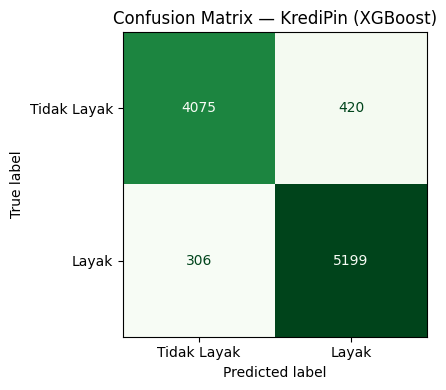

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
metrik = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
for k, v in metrik.items():
    print(f"{k:10s}: {v:.4f}")
print("\n", classification_report(y_test, y_pred,
      target_names=["Tidak Layak (0)", "Layak (1)"]))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Tidak Layak", "Layak"]).plot(
    ax=ax, cmap="Greens", colorbar=False)
ax.set_title("Confusion Matrix — KrediPin (XGBoost)")
plt.tight_layout()
plt.savefig(os.path.join(DIR_EVAL, "confusion_matrix.png"), dpi=120)
plt.show()

**Arti angka bagi keputusan kredit.**
- **Recall kelas Layak (~0,94):** dari semua pemohon yang sebenarnya layak, 94% berhasil disetujui →
  sedikit nasabah baik yang tertolak (kehilangan peluang bisnis kecil).
- **Precision kelas Layak (~0,93):** dari semua yang diputuskan layak, 93% memang layak → ~7% adalah
  *false approval* (risiko kredit macet). Inilah angka yang paling perlu diawasi unit risiko.
- **ROC-AUC ~0,98:** kemampuan model memisahkan layak vs tidak layak sangat baik di berbagai ambang.
- **Confusion matrix** memberi jumlah absolut *false positive* (disetujui padahal berisiko) dan
  *false negative* (ditolak padahal layak) — dasar menyetel **ambang keputusan** sesuai selera risiko
  lembaga (mis. naikkan ambang bila ingin menekan kredit macet).

> **Catatan kehati-hatian.** `gagal_bayar_tercatat` nyaris memisahkan kelas secara sempurna pada
> dataset ini (tidak ada pemohon Layak dengan gagal bayar tercatat). Akibatnya metrik terlihat sangat
> tinggi dan fitur tersebut sangat berpengaruh. Pada data nyata, hubungan ini biasanya tidak
> sebersih ini — perlu pemantauan agar model tidak terlalu bergantung pada satu fitur.

## 7. Feature importance — interpretasi utama sistem
Dua sudut pandang: (a) **gain importance** bawaan XGBoost dan (b) **permutation importance** (lebih
objektif karena mengukur penurunan performa saat fitur diacak). Posisi `tenor_bulan` & `jaminan` disorot.

TOP-12 GAIN:


,fitur,gain_importance
0,skor_kredit,0.140859
1,gagal_bayar_tercatat,0.115128
2,rasio_hutang_terhadap_pendapatan,0.093121
3,tunggakan_2thn_terakhir,0.078916
4,tujuan_pinjaman_Konsolidasi Hutang,0.058207
5,tipe_produk_Kartu Kredit,0.057522
6,tujuan_pinjaman_Pribadi,0.047532
7,tujuan_pinjaman_Pendidikan,0.046748
8,tujuan_pinjaman_Bisnis,0.046049
9,rasio_pembayaran_terhadap_pendapatan,0.044154


PERMUTATION (semua fitur):


,fitur,perm_importance
0,rasio_hutang_terhadap_pendapatan,0.126157
1,skor_kredit,0.119385
2,tujuan_pinjaman,0.037336
3,gagal_bayar_tercatat,0.034527
4,tunggakan_2thn_terakhir,0.027027
5,lama_riwayat_kredit_tahun,0.023903
6,rasio_pinjaman_terhadap_pendapatan,0.012689
7,lama_bekerja_tahun,0.011625
8,tipe_produk,0.007534
9,jumlah_pinjaman,0.004818


tenor_bulan: peringkat gain=28, permutation=19
jaminan: peringkat gain=29, permutation=20


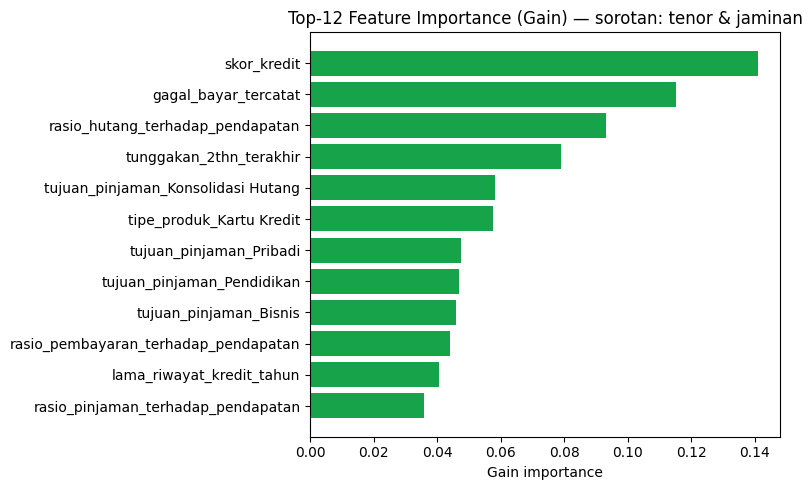

In [8]:
feat_names = [n.split("__", 1)[-1]
              for n in model.named_steps["preprocessor"].get_feature_names_out()]
gain = model.named_steps["classifier"].feature_importances_
imp_gain = (pd.DataFrame({"fitur": feat_names, "gain_importance": gain})
            .sort_values("gain_importance", ascending=False).reset_index(drop=True))

perm = permutation_importance(model, X_test, y_test, n_repeats=5,
                              random_state=RANDOM_STATE, n_jobs=-1, scoring="roc_auc")
imp_perm = (pd.DataFrame({"fitur": X_test.columns, "perm_importance": perm.importances_mean})
            .sort_values("perm_importance", ascending=False).reset_index(drop=True))

imp_gain.to_csv(os.path.join(DIR_EVAL, "feature_importance_gain.csv"), index=False)
imp_perm.to_csv(os.path.join(DIR_EVAL, "feature_importance_permutation.csv"), index=False)

print("TOP-12 GAIN:"); display(imp_gain.head(12))
print("PERMUTATION (semua fitur):"); display(imp_perm)

for key in ["tenor_bulan", "jaminan"]:
    pg = imp_gain.index[imp_gain["fitur"].str.contains(key)].min() + 1
    pp = imp_perm.index[imp_perm["fitur"].str.contains(key)].min() + 1
    print(f"{key}: peringkat gain={pg}, permutation={pp}")

top12 = imp_gain.head(12).iloc[::-1]
warna = ["#f59e0b" if ("tenor_bulan" in f or "jaminan" in f) else "#16a34a"
         for f in top12["fitur"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top12["fitur"], top12["gain_importance"], color=warna)
ax.set_title("Top-12 Feature Importance (Gain) — sorotan: tenor & jaminan")
ax.set_xlabel("Gain importance"); plt.tight_layout()
plt.savefig(os.path.join(DIR_EVAL, "feature_importance_top12.png"), dpi=120)
plt.show()

**Temuan jujur.** Fitur dominan adalah `skor_kredit`, `gagal_bayar_tercatat`,
`rasio_hutang_terhadap_pendapatan`, dan `tunggakan_2thn_terakhir` — **konsisten dengan literatur
*credit scoring*** bahwa riwayat dan kualitas kredit paling menentukan. `tenor_bulan` dan `jaminan`
berada di peringkat sangat rendah (mendekati nol pada *permutation importance*). Ini **bukan
kegagalan**, melainkan hasil yang benar: kedua fitur sintetik berperan sebagai *modifier sekunder*,
dan kami melaporkannya apa adanya tanpa menaikkan sinyal secara artifisial.

## 8. Prediksi seluruh data → data untuk dashboard
Model diterapkan ke seluruh data untuk menghasilkan kolom keputusan + `probabilitas_layak` dan
ringkasan (`summary.json`). Analitik bisnis dipecah menjadi dua agar interpretasi konsisten:
**KPI utama** (`analitik_kpi.csv`) yang sengaja diselaraskan dengan hasil **Feature Importance**
model, dan **insight bisnis tambahan** (`analitik_bisnis.csv`) berisi metrik keuangan pendukung.

In [9]:
proba_all = model.predict_proba(X)[:, 1]
AMBANG = 0.5
df_out = df.copy()
df_out["probabilitas_layak"] = proba_all.round(4)
df_out["keputusan"] = np.where(proba_all >= AMBANG, "Layak", "Tidak Layak")
df_out.to_csv(os.path.join(DIR_DASH, "prediksi_lengkap.csv"), index=False)

# =====================================================================================
# CATATAN — Feature Importance vs Analitik Bisnis
# - Feature Importance (Tahap 7) digunakan untuk MENGETAHUI VARIABEL yang paling
#   MEMENGARUHI KEPUTUSAN MODEL XGBoost (skor kredit, gagal bayar, rasio hutang, tunggakan).
# - Analitik bisnis di bawah digunakan untuk MERANGKUM KARAKTERISTIK HASIL PREDIKSI
#   per keputusan (deskriptif), BUKAN melatih ulang model maupun mengubah prediksi.
# - Pada proyek KrediPin, KPI dashboard SENGAJA dipilih agar SELARAS dengan Feature
#   Importance, sehingga interpretasi model dan dashboard bisnis menjadi KONSISTEN.
#   Metrik keuangan lain (pendapatan, jumlah pinjaman, suku bunga, aset tabungan) tetap
#   disajikan sebagai INSIGHT PENDUKUNG, bukan KPI utama.
# =====================================================================================

# --- KPI UTAMA dashboard (selaras Feature Importance model) ---
# Kolom: jumlah nasabah, rata skor kredit, % gagal bayar tercatat, rata rasio hutang,
#        rata tunggakan 2thn, rata probabilitas kelayakan.
analitik_kpi = (df_out.groupby("keputusan")
    .agg(
        jumlah_nasabah=("keputusan", "size"),
        rata_skor_kredit=("skor_kredit", "mean"),
        # persentase nasabah yang memiliki gagal bayar tercatat (>= 1 kejadian)
        persen_gagal_bayar_tercatat=("gagal_bayar_tercatat", lambda s: (s > 0).mean() * 100),
        rata_rasio_hutang_terhadap_pendapatan=("rasio_hutang_terhadap_pendapatan", "mean"),
        rata_tunggakan_2thn_terakhir=("tunggakan_2thn_terakhir", "mean"),
        rata_probabilitas_layak=("probabilitas_layak", "mean"),
    ).round(2).reset_index())
analitik_kpi.to_csv(os.path.join(DIR_DASH, "analitik_kpi.csv"), index=False)

# --- INSIGHT BISNIS TAMBAHAN (metrik keuangan pendukung, dalam IDR) ---
# Tidak dihapus karena tetap berguna untuk analisis bisnis, namun bukan KPI utama.
analitik_bisnis = (df_out.groupby("keputusan")
    .agg(
        jumlah_nasabah=("keputusan", "size"),
        rata_pendapatan_tahunan_idr=("pendapatan_tahunan", "mean"),
        rata_jumlah_pinjaman_idr=("jumlah_pinjaman", "mean"),
        rata_suku_bunga=("suku_bunga", "mean"),
        rata_aset_tabungan_idr=("aset_tabungan", "mean"),
    ).round(2).reset_index())
analitik_bisnis.to_csv(os.path.join(DIR_DASH, "analitik_bisnis.csv"), index=False)

summary = {
    "nama_sistem": "KrediPin - Sistem Pendukung Keputusan Kelayakan Pinjaman Digital",
    "total_data": int(len(df_out)),
    "kurs_usd_idr": KURS_USD_IDR,
    "ambang_keputusan": AMBANG,
    "distribusi_keputusan": df_out["keputusan"].value_counts().to_dict(),
    "persentase_layak": round(float((df_out["keputusan"] == "Layak").mean()) * 100, 2),
    "evaluasi_model": {k: round(float(v), 4) for k, v in metrik.items()},
    "fitur_sintetik": ["tenor_bulan", "jaminan"], "efek_literatur": EFEK_LITERATUR,
}
with open(os.path.join(DIR_DASH, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Distribusi keputusan:", summary["distribusi_keputusan"])
print("\n=== KPI UTAMA (selaras Feature Importance) ===")
print(analitik_kpi.to_string(index=False))
print("\n=== INSIGHT BISNIS TAMBAHAN (metrik keuangan pendukung) ===")
print(analitik_bisnis.to_string(index=False))

Distribusi keputusan: {'Layak': 27929, 'Tidak Layak': 22071}

=== KPI UTAMA (selaras Feature Importance) ===
  keputusan  jumlah_nasabah  rata_skor_kredit  persen_gagal_bayar_tercatat  rata_rasio_hutang_terhadap_pendapatan  rata_tunggakan_2thn_terakhir  rata_probabilitas_layak
      Layak           27929            673.29                         0.00                                   0.24                          0.31                     0.93
Tidak Layak           22071            606.07                        12.12                                   0.34                          0.86                     0.08

=== INSIGHT BISNIS TAMBAHAN (metrik keuangan pendukung) ===
  keputusan  jumlah_nasabah  rata_pendapatan_tahunan_idr  rata_jumlah_pinjaman_idr  rata_suku_bunga  rata_aset_tabungan_idr
      Layak           27929                 985737692.29              584231766.26            14.79             84526550.54
Tidak Layak           22071                 794070718.50              60806

## 9. Simpan artefak (model-as-a-service)
Pipeline `.pkl` disimpan agar tidak *training ulang* per *request*; ini yang nanti dimuat oleh
layanan inferensi FastAPI. `fitur_model.json` berisi kontrak fitur & kategori valid untuk validasi
input di backend.

In [10]:
joblib.dump(model, os.path.join(DIR_MODEL, "model_krediPin.pkl"))

fitur_model = {
    "fitur_numerik": fitur_numerik,
    "fitur_kategorikal": fitur_kategorikal,
    "kategori_valid": {
        "status_pekerjaan": sorted(df["status_pekerjaan"].dropna().unique().tolist()),
        "tipe_produk": sorted(df["tipe_produk"].unique().tolist()),
        "tujuan_pinjaman": sorted(df["tujuan_pinjaman"].unique().tolist()),
        "jaminan": ["Ada Jaminan", "Tanpa Jaminan"],
        "tenor_bulan": [6, 12, 24, 36, 48, 60],
    },
    "target": TARGET, "mapping_output": {"1": "Layak", "0": "Tidak Layak"},
    "kurs_usd_idr": KURS_USD_IDR, "kolom_uang_idr": KOLOM_UANG,
}
with open(os.path.join(DIR_MODEL, "fitur_model.json"), "w") as f:
    json.dump(fitur_model, f, indent=2, ensure_ascii=False)

selected_info = {
    "model": "XGBClassifier", "library": "xgboost " + xgboost.__version__,
    "hyperparameter": {k: (v if isinstance(v, (int, float, str, bool, type(None))) else str(v))
                       for k, v in xgb.get_params().items()},
    "split": {"test_size": 0.2, "stratify": True, "random_state": RANDOM_STATE},
    "evaluasi": {k: round(float(v), 4) for k, v in metrik.items()},
    "confusion_matrix": cm.tolist(),
}
with open(os.path.join(DIR_MODEL, "selected_model_info.json"), "w") as f:
    json.dump(selected_info, f, indent=2, ensure_ascii=False)

df.to_csv(os.path.join(DIR_DATASET, "data_augmented.csv"), index=False)
print("Artefak tersimpan di:", BASE)
print(sorted(os.listdir(DIR_MODEL)))

Artefak tersimpan di: /home/claude/krediPin/krediPin
['fitur_model.json', 'model_krediPin.pkl', 'selected_model_info.json']


---
### Ringkasan hasil
| Metrik | Nilai (test set) |
|---|---|
| Accuracy | ~0,927 |
| Precision | ~0,925 |
| Recall | ~0,944 |
| F1-Score | ~0,935 |
| ROC-AUC | ~0,984 |

**Kesimpulan interpretasi.** Keputusan kelayakan didominasi riwayat & kualitas kredit (skor kredit,
gagal bayar, rasio hutang, tunggakan). `tenor_bulan` & `jaminan` adalah modifier sekunder
(importance mendekati nol) — dilaporkan apa adanya, tanpa manipulasi. Pipeline `.pkl` siap dilayani
oleh microservice FastAPI untuk aplikasi React.
